In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('/content/height-weight.csv')

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [5]:
df.shape

(23, 2)

Text(0, 0.5, 'Height')

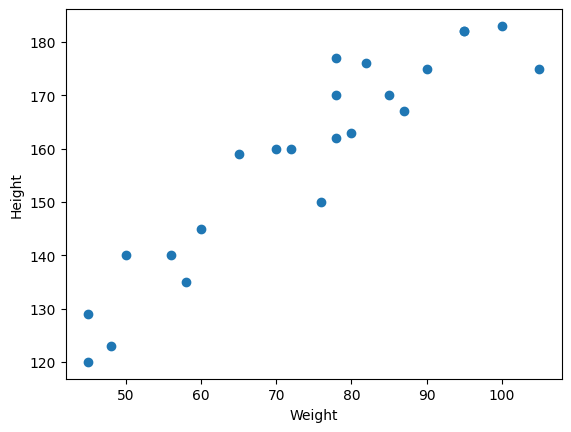

In [7]:
#Checking the relationship between features
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [9]:
# Correlation
df.corr() #Highly postive correlated value i.e 0.9311

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


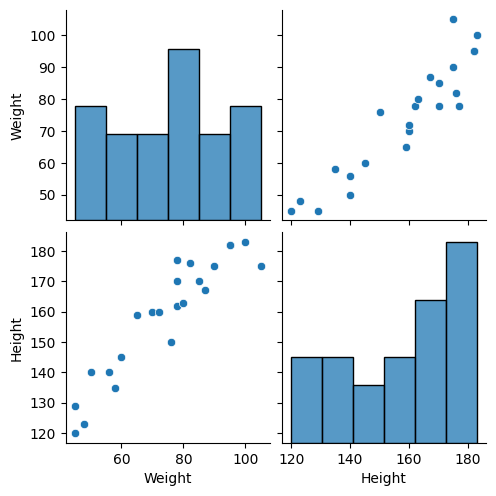

In [10]:
## Seaborn for visualization
sns.pairplot(df)

In [17]:
#Independent and Dependent Features
X = df[['Weight']]
y = df['Height']



In [18]:
## Train Test split
from sklearn.model_selection import train_test_split



In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)


(17, 1)

In [24]:
# Standarization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [27]:
# Applying Simple Linear Regression
from sklearn.linear_model import LinearRegression
regressor = LinearRegression(n_jobs=-1)
regressor.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [30]:
print("Coefficient or Slope",regressor.coef_)
print("Intercept",regressor.intercept_)

Coefficient or Slope [17.2982057]
Intercept 156.47058823529412


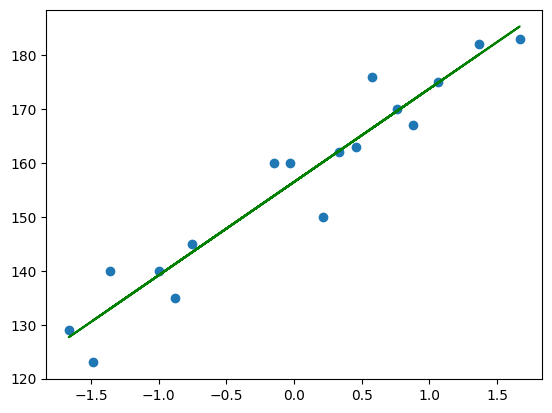

In [34]:
# Plot Training data plot of a slope or best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),color='green')


##Prediction of the Test Data
1 - Prediction heigh output = intercept +coef(weight)

2 - y_pred_test = 156.470 + 17.29(X_test)


In [35]:
# Prediction for Test Data
y_pred = regressor.predict(X_test)

In [36]:
#Performance Metrices
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse,mae,rmse)

114.84069295228699 9.66512588679501 10.716374991212605


In [37]:
#R Square
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(r2)

0.7360826717981276


In [38]:
# Adjusted R2
1-(1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [41]:
#OLS Linear Regression
import statsmodels.api as sn
model = sn.OLS(y_train,X_train).fit()
prediction = model.predict(X_test)
print(prediction)
print(model.summary())

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]
                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                       0.664
Time:                        18:55:32   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err       